# Prédiction de survie des passagers du Titanic
# Objectif
Construire un modèle de classification capable de prédire la probabilité de survie d'un passager.
# Problématique
Quels facteurs influencent significativement la surive?

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Analyse exploratoire des données (EDA)
Nous explorons la structure du dataset afin d'identifier :
- les types des variables,
- les valeurs manquantes,
- les distributions,
- les premières tendances.

In [76]:
df= pd.read_csv("../data/raw/titanic.csv")
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [77]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

On observe que certaines variables (Age, Cabin, Embarked) contiennent des valeurs manquantes.
Ces valeurs devront être traités avant la modélisation.

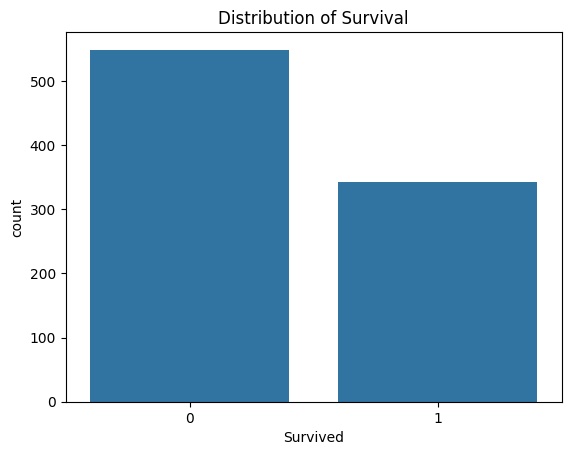

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="Survived", data=df)
plt.title("Distribution of Survival")
plt.show()

Grâce à ce graphique, on remarque que le nombre de passagers décédés est supérieur au nombre de survivants. Le dataset est donc légèrement déséquilibré.

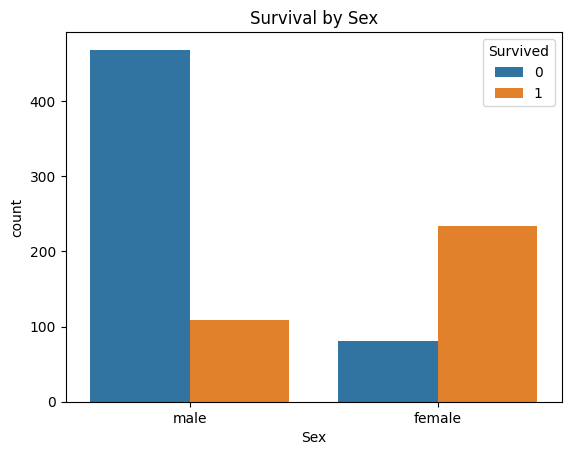

In [79]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Sex")
plt.show()

Les hommes présentent un taux de survie relativement faible comparé aux femmes. Celà pourrait s'expliquer par la priorité donnée aux femmes lors de l'évacuation.

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


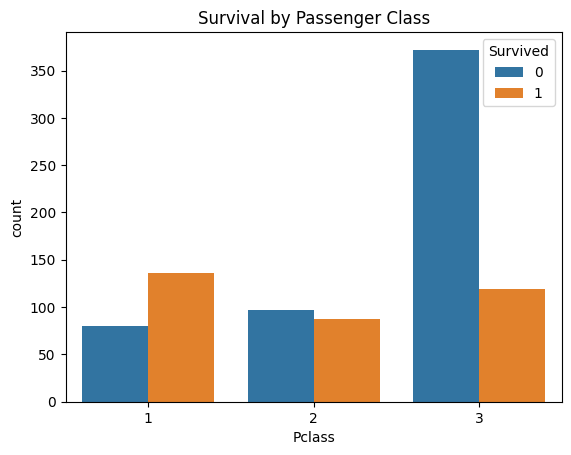

In [80]:
survival_rate_by_class = df.groupby("Pclass")["Survived"].mean()
print(survival_rate_by_class)
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

Le cacul du taux de survie montre une différence significative entre les classes.Les passagers de la classe 3 sont ceux qui ont subis le maximum de perte en vies humaines. Cela peut s'expliquer par le fait qu'ils étaient beaucoup plus nombreux sur le bateau que les autres classes. Cependant, les passagers de la classe 1 semblent présenter un taux de survie beaucoup plus élevé, ce qui suggère aussi un impact potentiel du statut socio-économique sur les chances de survie.

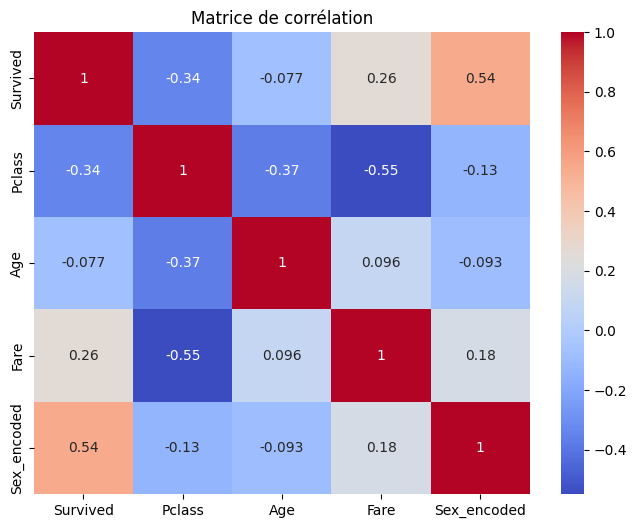

In [81]:
# Création d'une copie pour l'analyse
df_corr = df.copy()

# Encodage de la variable Sex
df_corr["Sex_encoded"] = df_corr["Sex"].map({"male" : 0, "female" : 1})

# Matrice de corrélation
plt.figure(figsize = (8,6))
sns.heatmap(df_corr[["Survived", "Pclass", "Age", "Fare", "Sex_encoded"]].corr(), annot = True, cmap = "coolwarm")
plt.title("Matrice de corrélation")
plt.show()


Après encodage de la variable Sex , on observe une forte corrélation positive entre le fait d'être une femme et la probabilité de survie.
Celà confirme l'importante du critère : "Women and children first" lors de l'évacuation.

# Préparation des données nécessaires à la modélisation
Avant d'entrainer le modèle, plusieurs éétapes sont nécessaires :
- Encodage de la variable Sex
- Imputation des valeurs manquantes
- Sélection des variables explicatives
Ces étapes permettent que les données soient exploitables par l'algorythme.

In [82]:
# Préparation des données pour la modélisation
df_model = df.copy()

# Encodage de Sex
df_model["Sex"] = df_model["Sex"].map({"male" : 0, "female" : 1})

# Gestion des valeurs manquantes 
df_model["Age"] = df_model["Age"].fillna(df_model["Age"].median())
df_model["Fare"] = df_model["Fare"].fillna(df_model["Fare"].median())

# Définition des variables
X = df_model[["Pclass", "Age", "Fare", "Sex"]]
y = df_model["Survived"]


# Modélisation
Nous utilsons une régression logistique pour prédire la survie des passagers.
La régression logistique est adaptée aux problèmes de classification binéaire, comme ici où la variable cible (Survived) prend les valeurs 0 et 1.

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy : ", accuracy_score(y_test, y_pred))

Accuracy :  0.8044692737430168


# Résultats
Le modèle obtient une accuracy d'environ 80% sur le jeu du test.
Celà signifie que le modèle prédit correctement la survie ou le décès de 80% de passagers dans 8 cas sur 10.
Cette performance est satisfaisante pour un modèle basé sur une régression logistique.
Cependant, l'accuracy seul ne suffit pas à totalement évaluer la performance sur chaque classe ( survivants vs non-survivants).

# Limites
- Aucune optimisation des hyperparamètres n'a été effectuée
- D'autres modèles pourraient potentiellement améliorer les performances.